# Swap-less implementation of the Multi controlled NOT

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Scripts.CnX_gates import (
    generate_cnx_logical_z_gates,
    decompose_many_body_rz_to_two_body,
    compress_cnx_decomposed_gates
)

from Scripts.CnX_spanning_lines import generate_cnx_lhz_spanning_lines
from Scripts.CnX_compiler import compile_cnx_with_lhz_spanning_lines
from Scripts.Circuit_plotter import draw_compiled_ops_pennylane

In [2]:
n_controls = 2

gates = generate_cnx_logical_z_gates(n_controls)

spanning_data = generate_cnx_lhz_spanning_lines(
    n_controls,
    return_cnot_steps=True,
    verbose=False,
)

compiled_ops, debug = compile_cnx_with_lhz_spanning_lines(
    gates,
    n_controls,
    spanning_data=spanning_data,
    return_debug=True,
    verbose=True,
)

print("CNOT count:", debug["cnot_count"])
print("Rotation count:", debug["rotation_count"])
print("CNOT depth:", debug["cnot_depth"])
print("Single-qubit depth:", debug["single_qubit_depth"])
print("Total greedy depth:", debug["total_greedy_depth"])

Placed initial H as ['H', [2], 'N/A']
Placed ['RZ', [0], 0.7853981633974483] on line 0 [(0,), (1,), (2,), (3,)] as ['RZ', [0], 0.7853981633974483]
Placed ['RZ', [1], 0.7853981633974483] on line 0 [(0,), (1,), (2,), (3,)] as ['RZ', [1], 0.7853981633974483]
Placed ['RZ', [2], 0.7853981633974483] on line 0 [(0,), (1,), (2,), (3,)] as ['RZ', [2], 0.7853981633974483]
Moved C^nX line 0 -> 1: [(0,), (1,), (2,), (3,)] -> [(0, 1), (1,), (2,), (3,)]
    ['CNOT', [1, 0], 'N/A']
Placed ['RZ', [0, 1], -0.7853981633974483] on line 1 [(0, 1), (1,), (2,), (3,)] as ['RZ', [0], -0.7853981633974483]
Moved C^nX line 1 -> 2: [(0, 1), (1,), (2,), (3,)] -> [(0, 1), (0, 2), (2,), (3,)]
    ['CNOT', [2, 1], 'N/A']
    ['CNOT', [0, 1], 'N/A']
Placed ['RZ', [0, 2], -0.7853981633974483] on line 2 [(0, 1), (0, 2), (2,), (3,)] as ['RZ', [1], -0.7853981633974483]
Moved C^nX line 2 -> 3: [(0, 1), (0, 2), (2,), (3,)] -> [(1, 2), (0, 2), (2,), (3,)]
    ['CNOT', [1, 0], 'N/A']
Placed ['RZ', [1, 2], -0.7853981633974483]

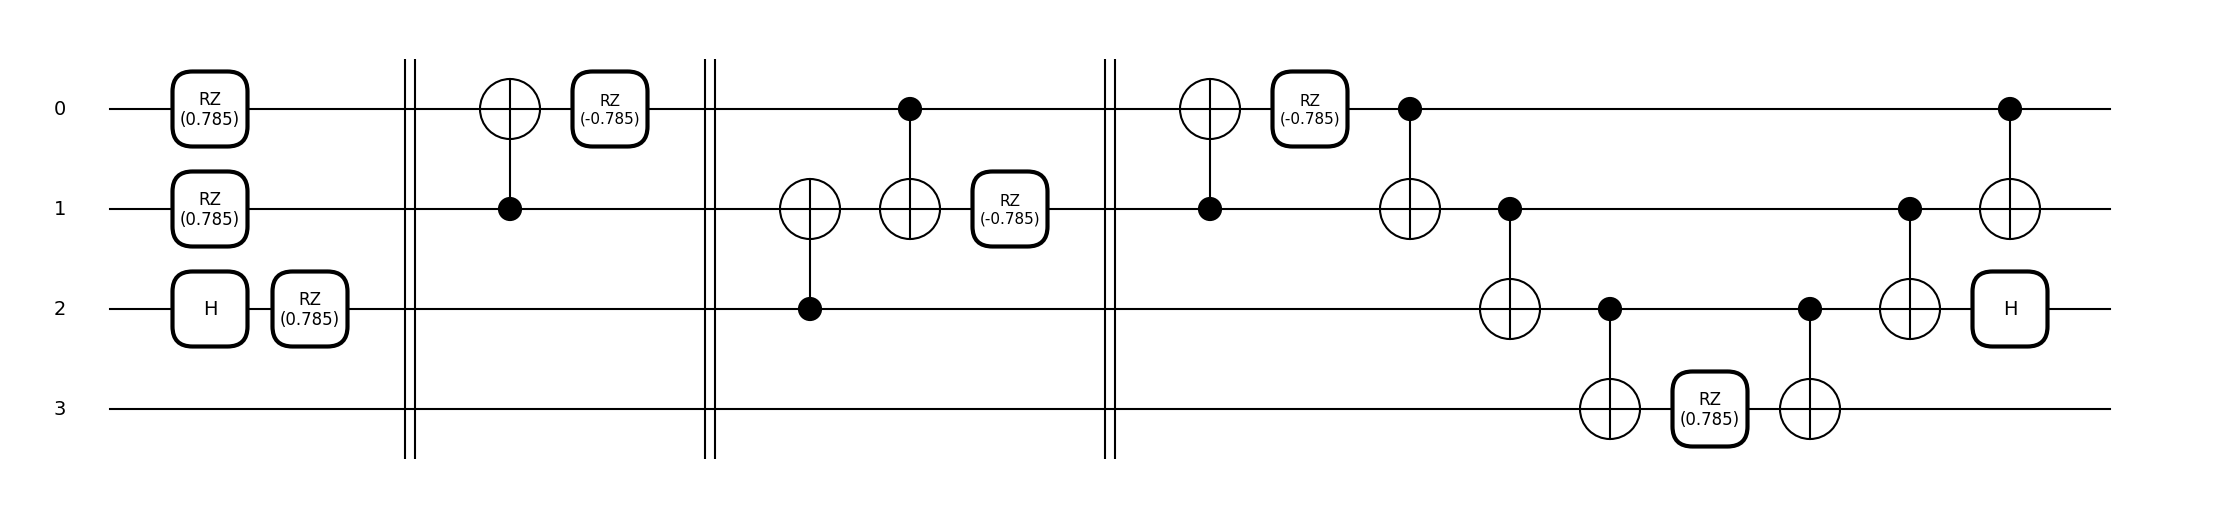

In [3]:
fig, ax = draw_compiled_ops_pennylane(compiled_ops, debug, n_wires = n_controls + 1)
fig.savefig(fname=f'Figures/Toffoli.pdf', bbox_inches='tight')